## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization_logreg import LogRegScalarization

## Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
PREFIX_SAVE_IMAGE = 'images/2_objs'

In [6]:
data = pd.read_csv('dataset/compas_onerace.csv')
data = data.drop('Unnamed: 0', axis=1)

fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


### Dataset Analysis

In [7]:
raw_data = pd.read_csv('dataset/compas-scores-two-years.csv')
#raw_data.head(3)

In [8]:
print(f'Dataset Size    : {len(data)}')
print(f'Train Set Size  : {len(X_train)}')
print(f'Raw dataset Size: {len(raw_data)}')

Dataset Size    : 6172
Train Set Size  : 3086
Raw dataset Size: 7214


In [9]:
print(f'Dataset Features    : {len(data.columns)}')
print(f'Raw Dataset Features: {len(raw_data.columns)}')

Dataset Features    : 7
Raw Dataset Features: 53


In [10]:
datasets = [('Dataset', data['not_white']),
            ('Train Set', X_train['not_white']),
            ('Test Set', X_test['not_white'])]

print(f'{'Set':<10} | {'White (count/%)':>15} | {'Non-White (count/%)':>15} | {'Total':>8}')
print('-' * 62)

for name, col in datasets:
    counts = col.value_counts()
    total = len(col)
    white = counts.get(0, 0)
    non_white = counts.get(1, 0)
    white_pct = white / total * 100
    non_white_pct = non_white / total * 100
    print(f'{name:<10} | {white:>6} ({white_pct:>5.1f}%) | {non_white:>10} ({non_white_pct:>5.1f}%) | {total:>8}')

Set        | White (count/%) | Non-White (count/%) |    Total
--------------------------------------------------------------
Dataset    |   2103 ( 34.1%) |       4069 ( 65.9%) |     6172
Train Set  |   1051 ( 34.1%) |       2035 ( 65.9%) |     3086
Test Set   |   1052 ( 34.1%) |       2034 ( 65.9%) |     3086


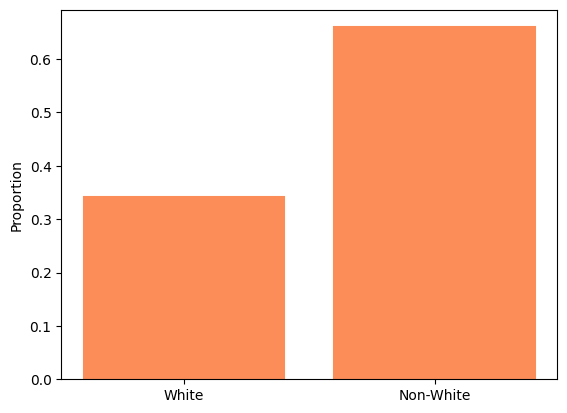

In [ ]:
import matplotlib.pyplot as plt

#plt.figure(figsize=(6,4))
colors = ['#fc8d59', '#fc8d59']

counts = X_train['not_white'].value_counts(normalize=True).sort_index().to_list()

plt.bar([0, 1], counts, color=colors, edgecolor='#fc8d59', linewidth=1.5)
plt.xticks([0,1], ['White','Non-White'], rotation=0)
#plt.title('Distribution of Race in Training Set (%)')
plt.ylabel('Proportion')
plt.savefig(f"images/compas_analysis.pdf", bbox_inches="tight")
plt.show()

### Suppress ConvergenceWarning from scikit-learn's LogisticRegression.

In [12]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from scikit-learn's LogisticRegression.
# These warnings indicate that the solver did not converge within the
# default number of iterations. In this project we are aware of this 
# behavior but choose not to address it here, as it does not affect 
# the focus of our experiments. Therefore, the warnings are silenced 
# to avoid cluttering the logs and console output.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [13]:
#import logging
#
#logging.captureWarnings(True)
#logging.getLogger('py.warnings').setLevel(logging.ERROR)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * NISE
    * MONISE
    * Random Weights

In [14]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}

num_objs = 2
objectives_names = ['White', 'Non-White']
results = {}

In [15]:
# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

In [16]:
# Logistic Regression Config for MOO
tol = 10**-8
max_iter = 10

In [17]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(
    num_objs=num_objs,
    X=X_train, 
    y=y_train, 
    fair_feat=fair_feature,
    #tol=tol, max_iter=max_iter
)
equal.optimize(np.array([0.5, 0.5]))

In [18]:
def machine_optimize(method, lb_estimate=0.01):
    w_scalar = LogRegScalarization(
        num_objs=num_objs, 
        X=X_train, 
        y=y_train,
        fair_feat=fair_feature,
        tol=tol,
        max_iter=max_iter, 
        lower_bound_estimate=lb_estimate  # Options: 'zero', 'lipschitz', or a float value
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    'moopt': moopt,
                    'objectives': objs,
                    'models': get_models(moopt),
                    'hypervolume': hypervolume_values
                }

In [19]:
def plot_frontier(method, color='#d73027'):
    title='Loss Trade-offs for White and Non-White Person'
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                subset=equal.objs,
                color=color,
                fontsize=20,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [20]:
method = 'mola'
machine_optimize(method=method)

<Figure size 1000x700 with 0 Axes>

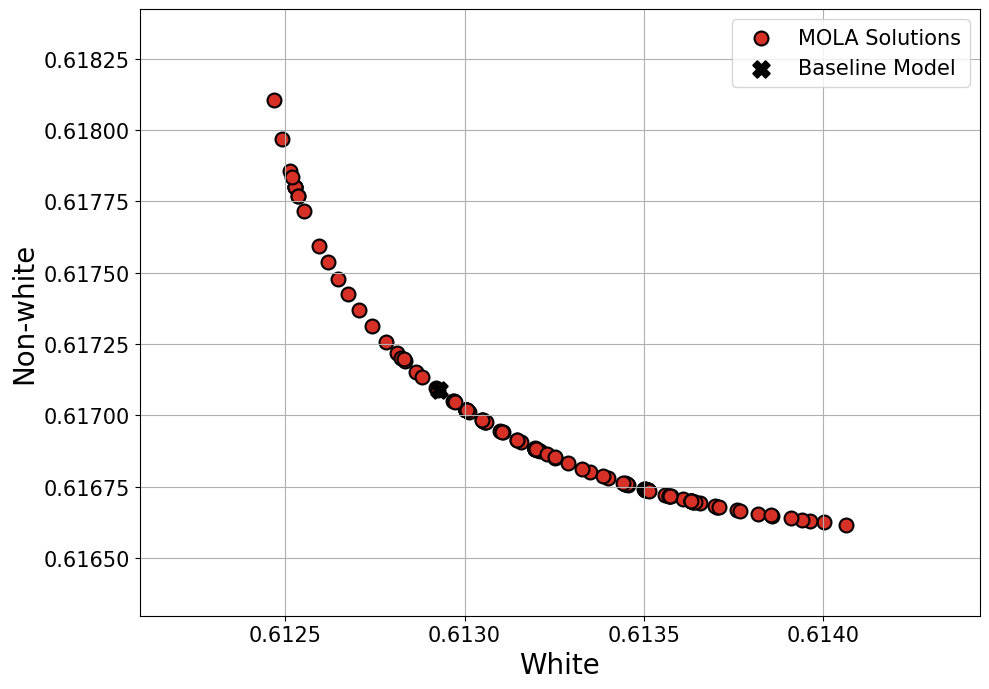

In [21]:
plot_frontier(method, color='#d73027')

### MOLA with gradient

In [22]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

<Figure size 1000x700 with 0 Axes>

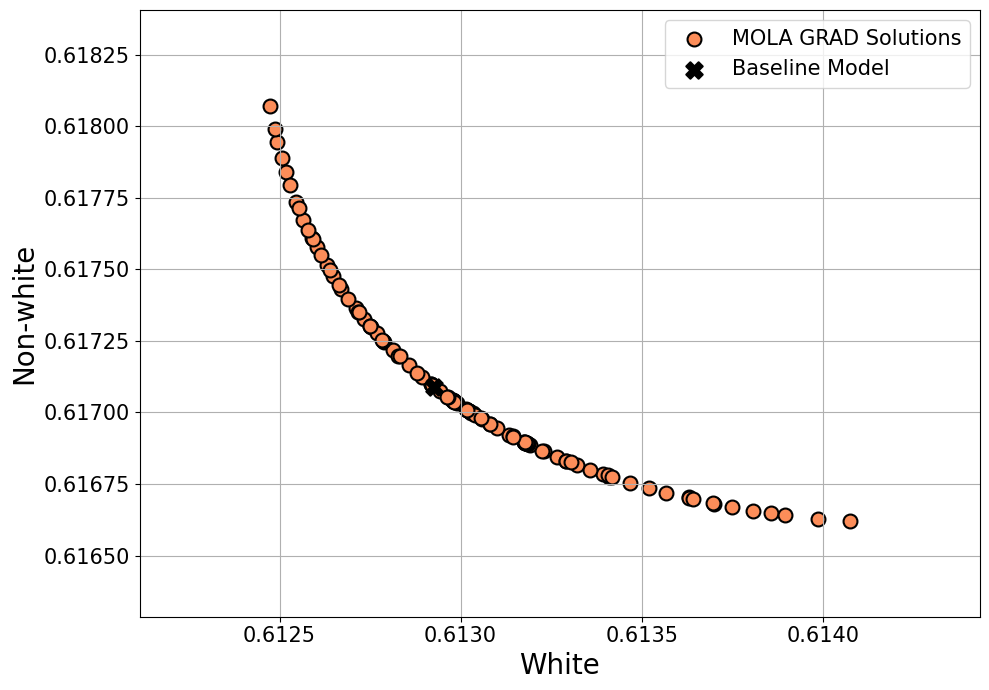

In [23]:
plot_frontier(f'{method}_grad', color='#fc8d59')

### Ramdon Weighted Sum

In [24]:
method = 'random_weight'
machine_optimize(method=method)

### NISE

In [25]:
method = 'nise'
machine_optimize(method=method)

/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warning

### MONISE

In [26]:
method = 'monise'
machine_optimize(method=method)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<Figure size 3000x1400 with 0 Axes>

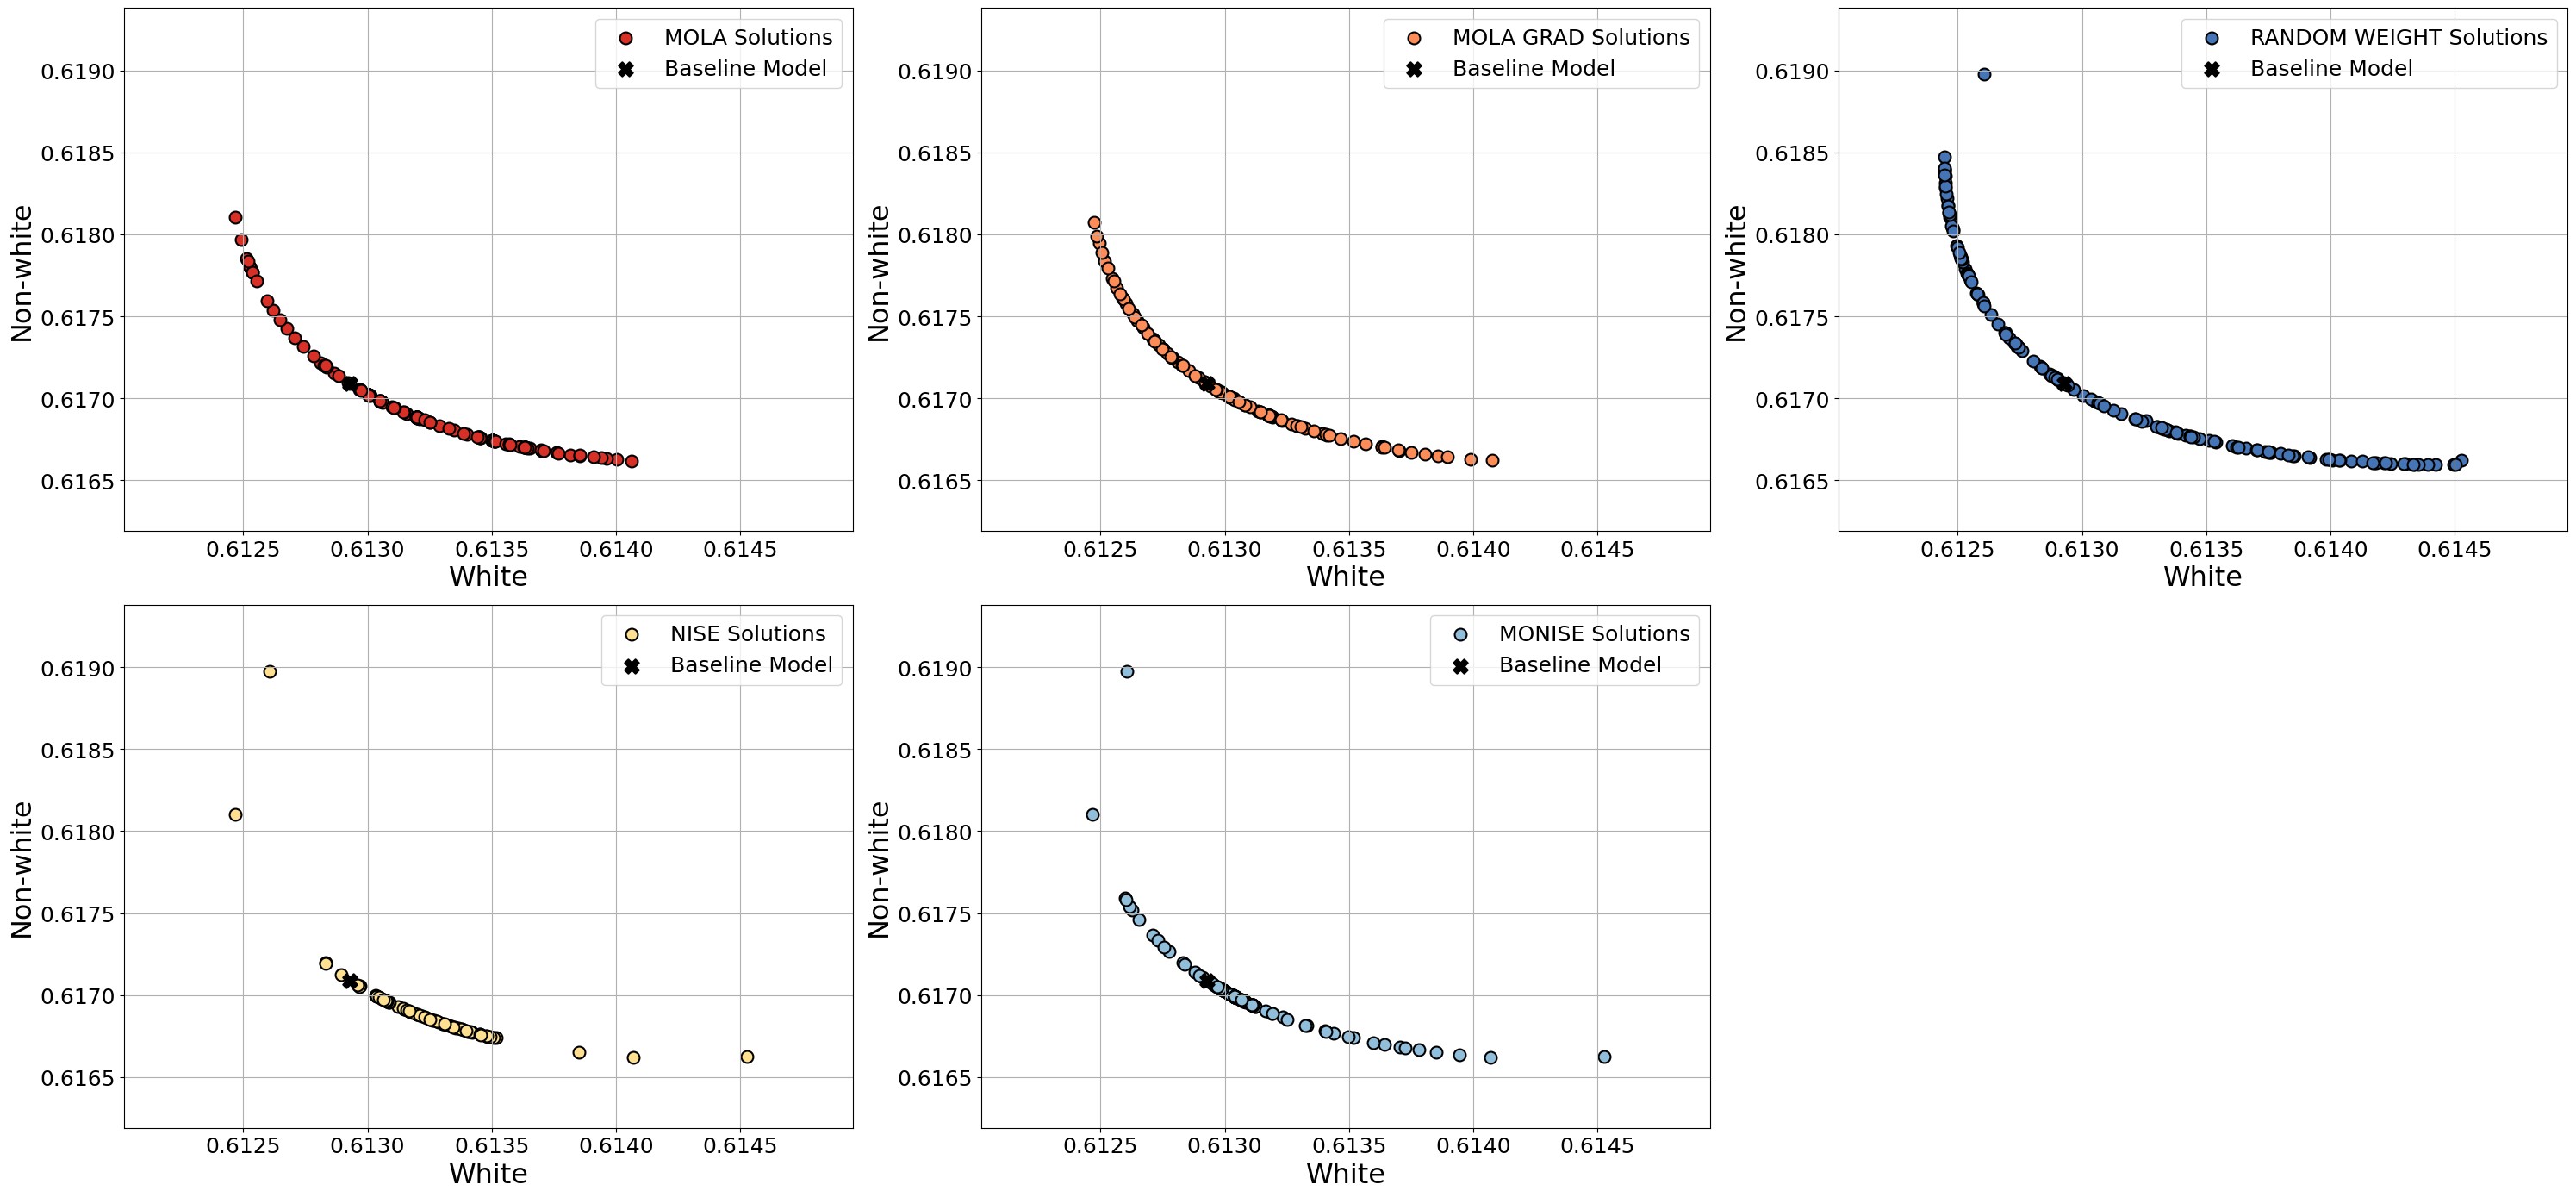

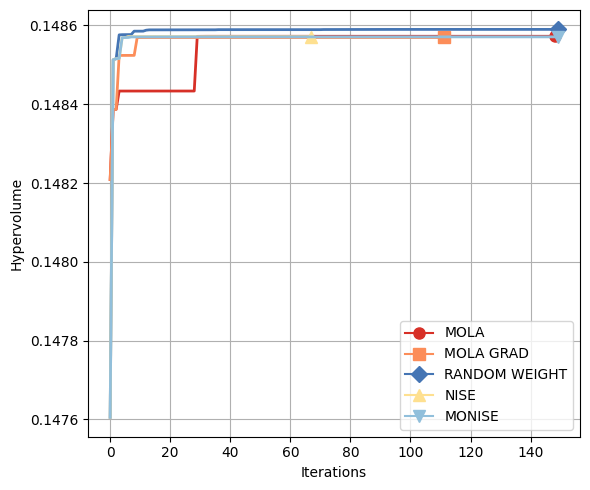

<Figure size 640x480 with 0 Axes>

In [27]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if ('objectives' in res)
    }

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            subset=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [ ]:
import pickle

# salvar
with open("results_reglog_2_objs.pkl", "wb") as f:
    pickle.dump(pareto_dict, f)

# ler depois
#with open("results_adam_2_objs.pkl", "rb") as f:
#    outro_dict = pickle.load(f)

### Non-dominated Solutions Analysis

In [28]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

In [29]:
## MOLA get only non dominated solutions
print(f'Number of non-dominated solutions with MOLA        : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD   : {len(results['mola_grad']['objectives'])}')

Number of non-dominated solutions with MOLA        : 141
Number of non-dominated solutions with MOLA GRAD   : 108


In [30]:
non_dominated_dict = {}

for method, res in results.items():
    if 'objectives' not in res:
        continue 

    solutions = res['objectives']

    # Indetify non-dominated solutions index
    nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)
    non_dominated_solutions = solutions[nd_indices]

    # Guarda no dicionário
    non_dominated_dict[method] = non_dominated_solutions

    print(f'Number of non-dominated solutions with {method.upper():<15}: {len(non_dominated_solutions)}')

Number of non-dominated solutions with MOLA           : 141
Number of non-dominated solutions with MOLA_GRAD      : 108
Number of non-dominated solutions with RANDOM_WEIGHT  : 139
Number of non-dominated solutions with NISE           : 64
Number of non-dominated solutions with MONISE         : 147


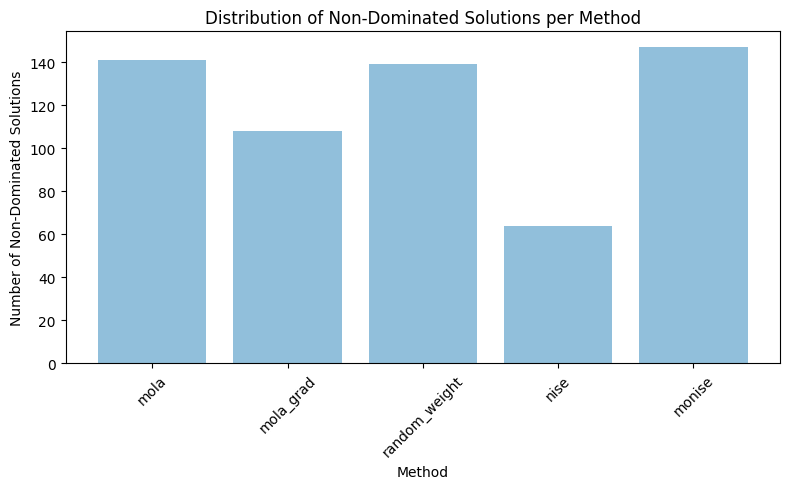

In [31]:
import matplotlib.pyplot as plt

# Number of non dominated solutions per method
nd_counts = {method: len(sols) for method, sols in non_dominated_dict.items()}

# bar plot
plt.figure(figsize=(8, 5))
plt.bar(nd_counts.keys(), nd_counts.values(), color='#91bfdb')
plt.xlabel('Method')
plt.ylabel('Number of Non-Dominated Solutions')
plt.title('Distribution of Non-Dominated Solutions per Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

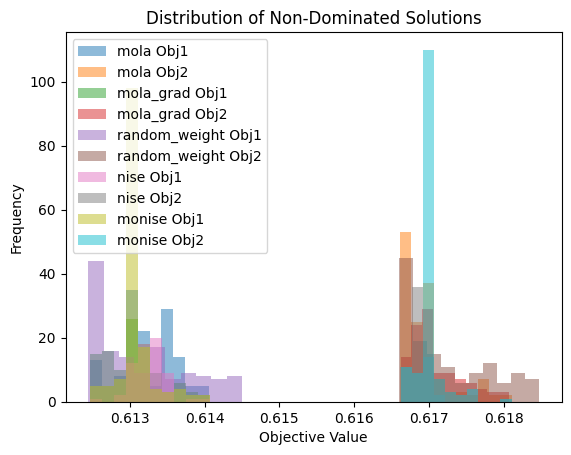

In [32]:
for method, sols in non_dominated_dict.items():
    plt.hist(sols[:,0], alpha=0.5, label=f'{method} Obj1')
    plt.hist(sols[:,1], alpha=0.5, label=f'{method} Obj2')

plt.xlabel('Objective Value')
plt.ylabel('Frequency')
plt.title('Distribution of Non-Dominated Solutions')
plt.legend()
plt.show()

### Ensemble

In [33]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from machinemoo.analysis.ensembles import voting_ensemble

In [34]:
lambd = math.exp(-100)
clf = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           #max_iter = max_iter,
                           #tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
accuracy_logreg = accuracy_score(y_test, pred)

In [35]:
#Logistic Regression Single Objctive
print(f'Logistic Regression Accuracy: {accuracy_logreg*100:.2f}%')

Logistic Regression Accuracy: 66.72%


In [36]:
## Aggregation with trained models obtained with MOO
ensembles = {}
for method in results.keys():
    y_pred = voting_ensemble(
        models=results[method]['models'], 
        X=X_test,  
        voting='hard',
        task='classification'
    )
    
    acc = accuracy_score(y_test, y_pred)
    
    ensembles[method] = {
        'acc_voting': acc,
        'y_pred': y_pred
    }

In [37]:
for method, ensemble in ensembles.items():
    print(f'  Accuracy {method.upper():<15}: {ensemble['acc_voting']*100:6.2f}%')

  Accuracy MOLA           :  66.88%
  Accuracy MOLA_GRAD      :  66.72%
  Accuracy RANDOM_WEIGHT  :  66.75%
  Accuracy NISE           :  66.72%
  Accuracy MONISE         :  66.75%


In [38]:
equal_model = equal.x
predictions = equal_model.predict(X_test)
accuracy_equal = accuracy_score(y_test, predictions)
print(f'Accuracy of Logistic Regression with Equal Weights {accuracy_equal*100:.2f}%')

Accuracy of Logistic Regression with Equal Weights 66.75%


In [39]:
# Print all accuracy for comparison
print(f'{'Method':<21} | {'Accuracy (%)':>12}')
print('-' * 36)

for method, ensemble in ensembles.items():
    acc = ensemble['acc_voting'] * 100
    print(f'{method.upper():<21} | {acc:>8.2f}')

print(f'{'Logistic Regression':<21} | {accuracy_logreg*100:>8.2f}')
print(f'{'Log Reg Equal Weights':<21} | {accuracy_equal*100:>8.2f}')

Method                | Accuracy (%)
------------------------------------
MOLA                  |    66.88
MOLA_GRAD             |    66.72
RANDOM_WEIGHT         |    66.75
NISE                  |    66.72
MONISE                |    66.75
Logistic Regression   |    66.72
Log Reg Equal Weights |    66.75


### Best Solution Criteria - Analysis with MOLA

In [40]:
from machinemoo.analysis.decision import select_lowest_median_solution, select_weighted_solution

In [41]:
mola = results['mola']

In [42]:
# Objective weights: higher values increase priority, balance defined by the weight vector
weights_vector = [2, 6]
solution_weighted = select_weighted_solution(mola['objectives'], mola['models'], weights_vector)
print(solution_weighted)

{'index': 33, 'score': 0.6159310295688948, 'objectives': [0.6135578026793101, 0.6167221051987564], 'models': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}


<Figure size 1000x700 with 0 Axes>

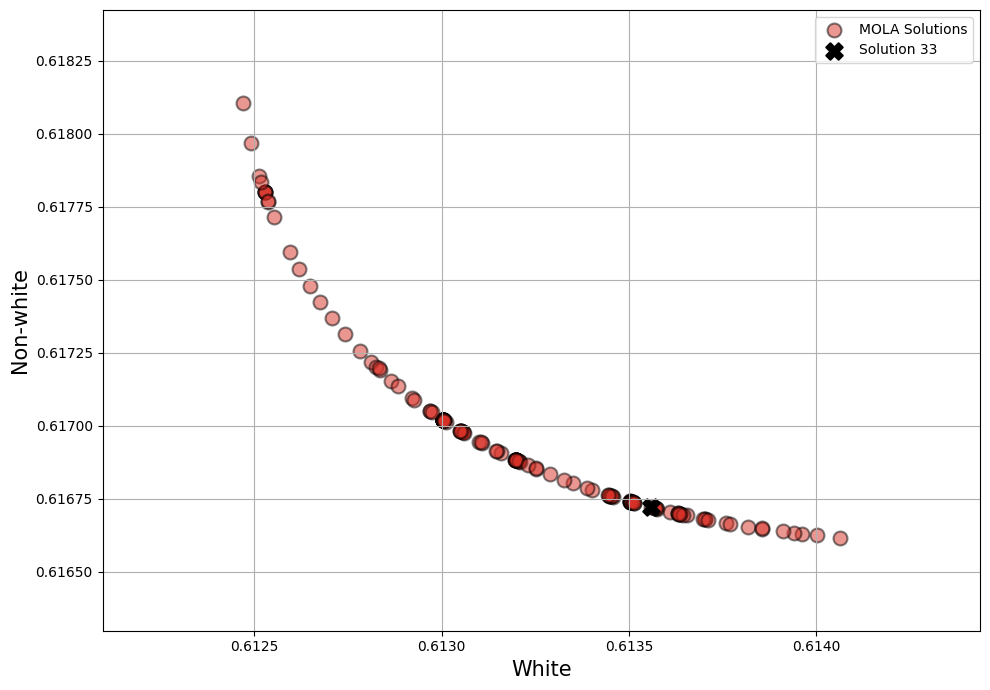

In [43]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            #title=title,
            fontsize=15,
            figsize=(10,7),
            subset=solution_weighted['objectives'],
            subset_label=f'Solution {solution_weighted['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_weighted.pdf',
            alpha=0.5,
            s_factor=2
            )

In [47]:
print(type(mola['objectives']))
print(len(mola['objectives']))
print(type(mola['objectives'][0]), mola['objectives'][0])

<class 'numpy.ndarray'>
141
<class 'numpy.ndarray'> [0.61351258 0.61673734]


In [61]:
# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0
solution_median = select_lowest_median_solution(objectives=mola['objectives'], models=mola['models'])
print(solution_median)

# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0 
# and values above a predefined threshold.
# Thresholds can be set per objective using a dictionary: {objective_index: max_value}.
# Here, the 1st objective has a threshold of 6128.
solution_median_threshold = select_lowest_median_solution(
    objectives=mola['objectives'],
    models=mola['models'],
    objective_thresholds={0: 0.6125})
print(solution_median_threshold)

{'index': 37, 'score': 0.6150081192034287, 'objectives': [0.6129209167439164, 0.6170953216629411], 'models': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}
{'index': 28, 'score': 0.6152295286023328, 'objectives': [0.6124901526349561, 0.6179689045697094], 'models': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}


In [62]:
# Analysis three solutions
subset = [
    solution_weighted['objectives'],
    solution_median['objectives'],
    solution_median_threshold['objectives']
]

labels = [
    f'Solution {solution_weighted['index']:<4} - Weighted',
    f'Solution {solution_median['index']:<3} - Median',
    f'Solution {solution_median_threshold['index']:<3} - Median Threshold'
]
markers = ['X', 'o', 's']

<Figure size 1000x700 with 0 Axes>

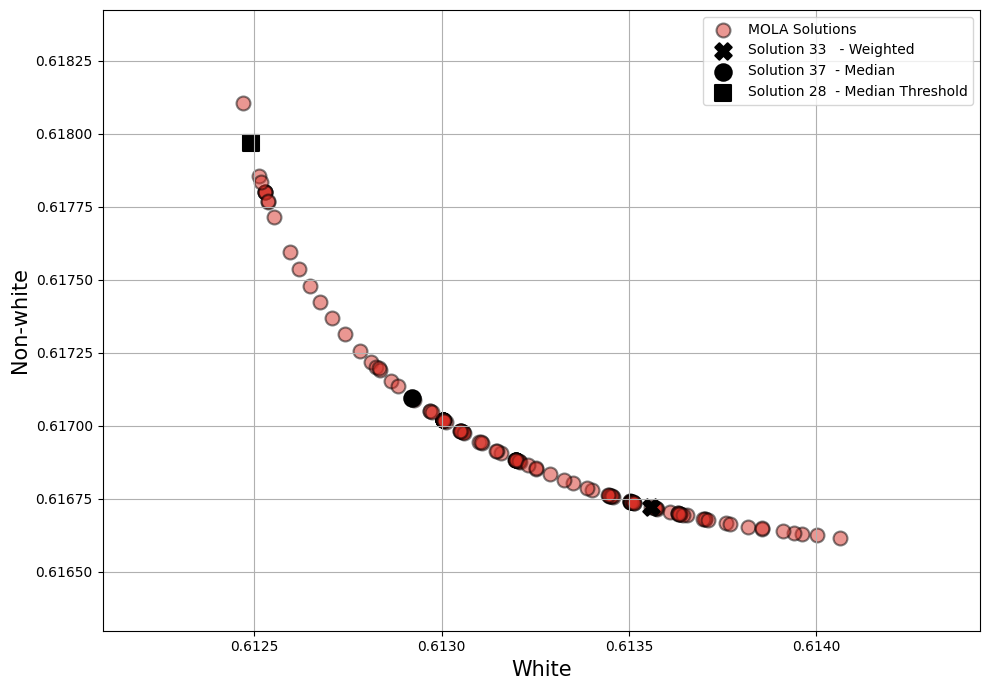

In [63]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            # title=title,
            fontsize=15,
            figsize=(10,7),
            subset=subset,
            subset_label=labels,
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_decision.pdf',
            alpha=0.5,
            s_factor=2,
            subset_marker=markers
            )

## Other Convergence Metrics

In [66]:
# With pymoo
from pymoo.indicators.igd import IGD
from pymoo.indicators.gd_plus import GDPlus
#from pymoo.indicators.spacing import Spacing

# Example: reference_front is the true or merged Pareto front
# solutions is the nondominated set obtained by a method

In [67]:
all_solutions = np.vstack([results['mola']['objectives'], results['mola_grad']['objectives'], results['nise']['objectives'], results['monise']['objectives'], results['random_weight']['objectives']])
nds = NonDominatedSorting().do(solutions, only_non_dominated_front=True)
reference_front = all_solutions[nds]

In [68]:
igd = IGD(reference_front)
print(f'{'Method':<13} | {'Inverted Generational Distance':>15}')
print('-' * 46)

for method, res in results.items():
    if 'objectives' in res:
        spacing = igd.do(res['objectives'])
        print(f'{method.upper():<13} | {spacing:>13.2e}')

Method        | Inverted Generational Distance
----------------------------------------------
MOLA          |      9.17e-07
MOLA_GRAD     |      9.54e-06
RANDOM_WEIGHT |      8.55e-06
NISE          |      5.91e-05
MONISE        |      2.22e-05


In [69]:
gd = GDPlus(reference_front)

print(f'{'Method':<13} | {'Generational Distance Plus':>15}')
print('-' * 42)

for method, res in results.items():
    if 'objectives' in res:
        spacing = gd.do(res['objectives'])
        print(f'{method.upper():<13} | {spacing:>13.2e}')

Method        | Generational Distance Plus
------------------------------------------
MOLA          |      2.75e-08
MOLA_GRAD     |      5.95e-06
RANDOM_WEIGHT |      6.01e-05
NISE          |      2.39e-05
MONISE        |      1.31e-05


# Only for dissertation

<Figure size 1000x700 with 0 Axes>

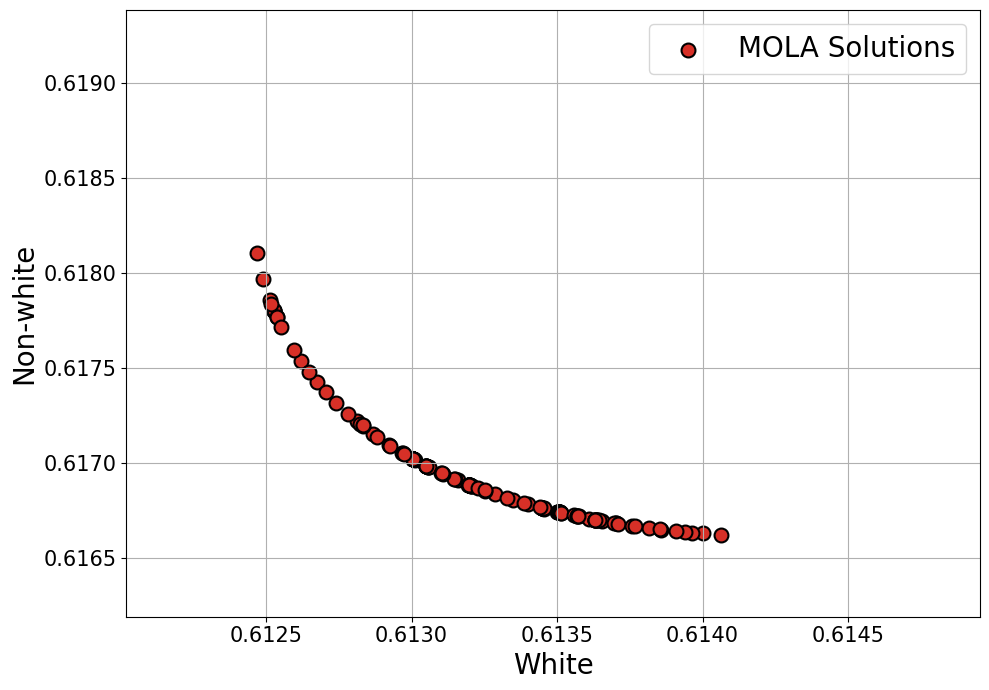

<Figure size 1000x700 with 0 Axes>

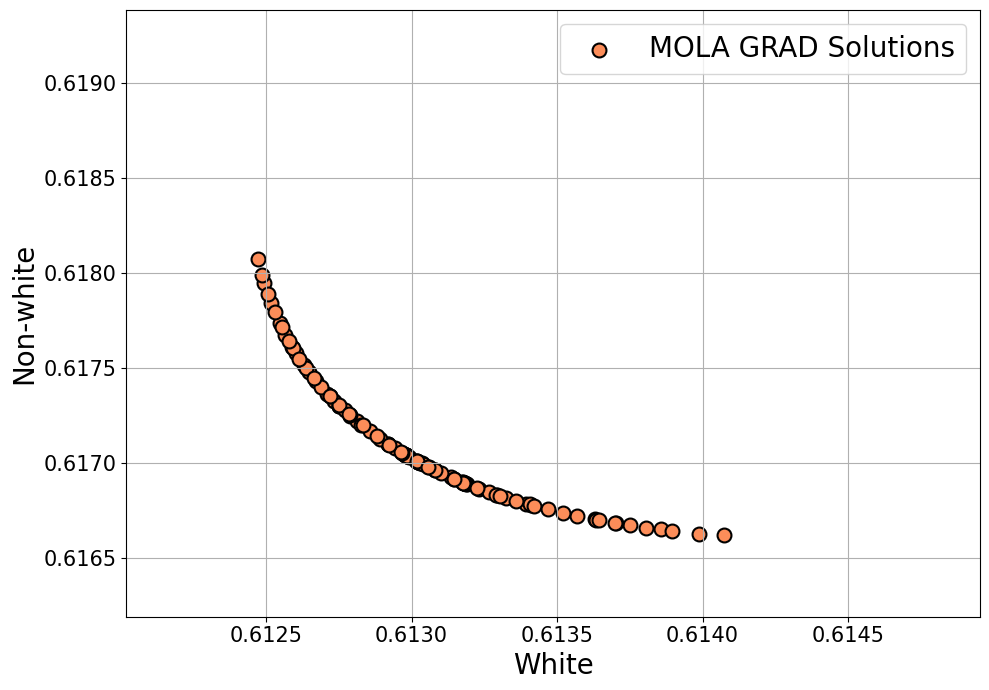

<Figure size 1000x700 with 0 Axes>

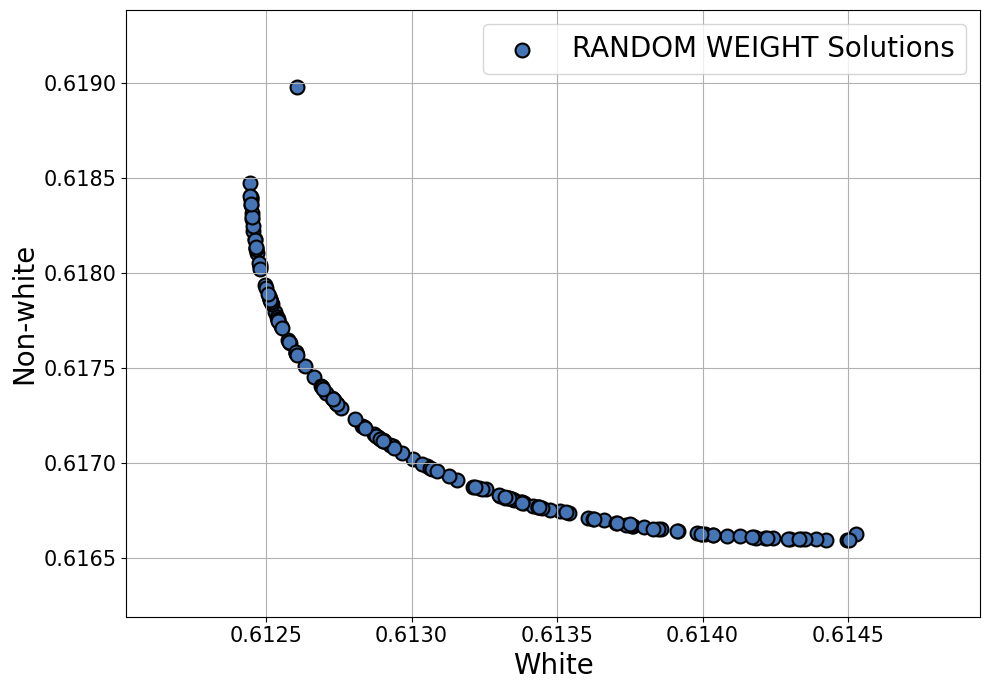

<Figure size 1000x700 with 0 Axes>

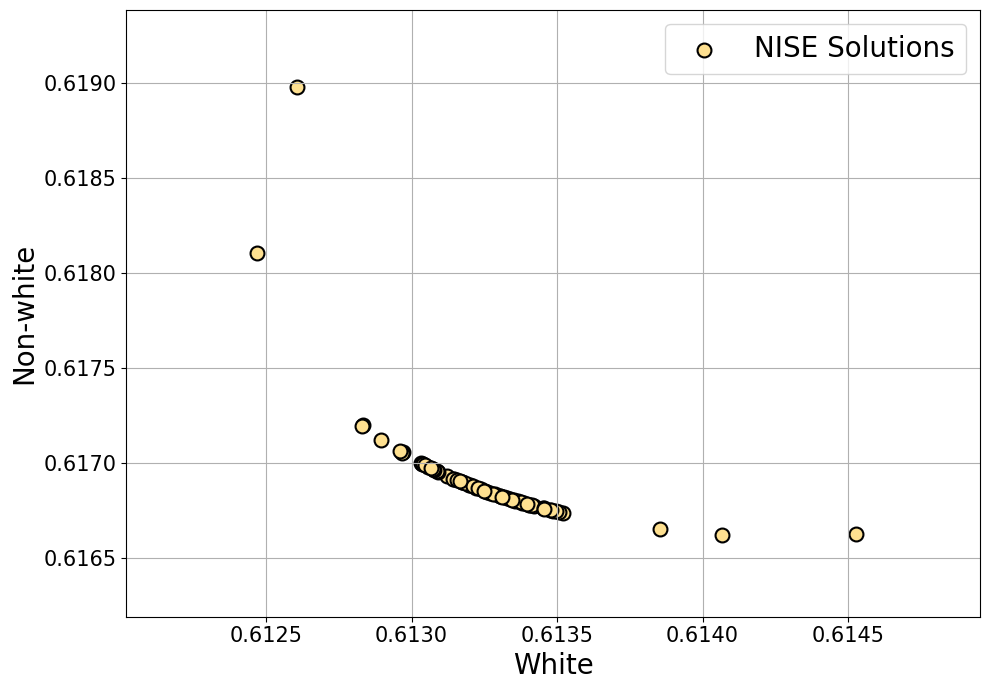

<Figure size 1000x700 with 0 Axes>

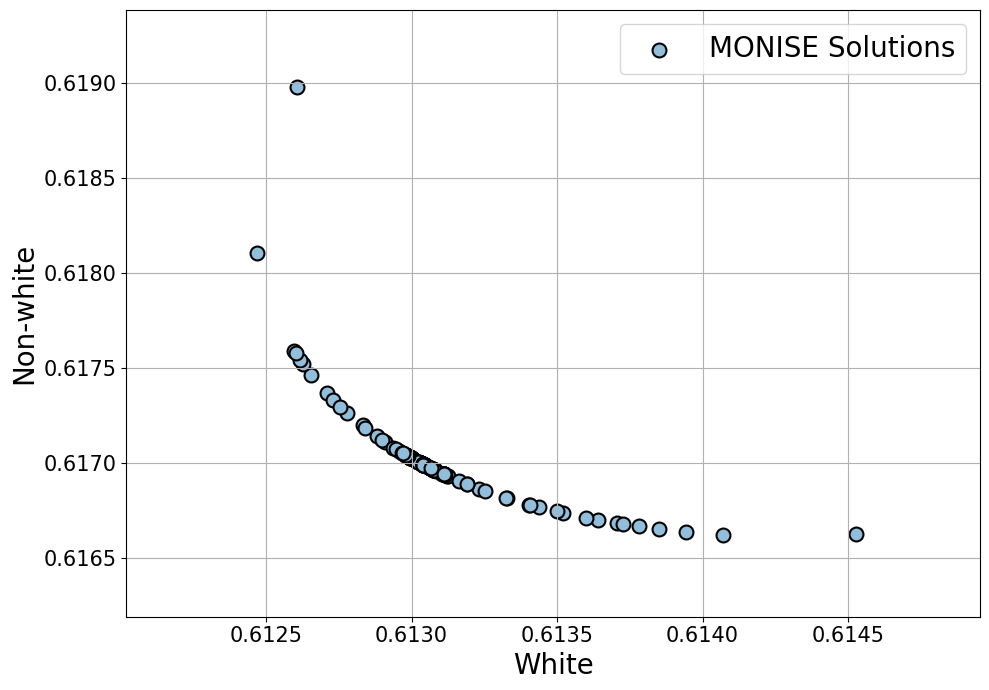

In [65]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4', '#fee090', '#91bfdb', '#e0f3f8']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )
#first_objs = next(iter(pareto_dict.values()))
#x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
#y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
#z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

#limits.append((x_min, x_max))
#limits.append((y_min, y_max))
#limits.append((z_min, z_max))
for i, (method, objs) in enumerate(pareto_dict.items()):
    plot_pareto(methods={method: objs},
                color = color[i],
                labels=objectives_names, 
                #title=title,
                fontsize=20,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}_limit.pdf',
                limits=limits
    )